In [11]:
import cfe

cfe.logger.setLevel("DEBUG")

In [12]:
fadata = cfe.data.read_pancrease()

# fadata = cfe.data.read_pancrease(n_obs=500)
# fadata.add_prior_information(start_cell="cell_000") # add prior information mannually

fadata

[09/16/2025 11:21:00] DEBUG    transfer 'X' and 'Spliced' matrix from csr to csc for better dynverse docker performance                                                                                 
                      DEBUG    Create a FateAnnData object from an existing AnnData object.                                                                                                             
                      DEBUG    recognize 'clusters' in '.obs' columns as 'cluster' key                                                                                                                  
                      DEBUG    recognize 'X_umap' in '.obsm' keys as 'basis' key                                                                                                                        
                      DEBUG    add prior information 'start_cell': 'cell_1103'                                                                                                                      

AnnData object with n_obs × n_vars = 3696 × 27998
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score'
    var: 'highly_variable_genes'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'neighbors', 'pca', 'cfe'
    obsm: 'X_pca', 'X_umap'
    layers: 'spliced', 'unspliced', 'expression', 'counts'
    obsp: 'distances', 'connectivities'

                      DEBUG    start_milestone is None, try to use start cell to identify start milestone automatically                                                                                 
                      DEBUG    extract start_cell('cell_1103') from prior information                                                                                                                   
                      DEBUG    find start milestone 'Ductal' from start cell 'cell_1103'                                                                                                                
                      DEBUG    calculating new pseudotime                                                                                                                                               
[09/16/2025 11:21:04] DEBUG    save pseudotime to trajectory dict with key: `pseudotime_from_Ductal`                                                                                                

<Axes: title={'center': 'trajectory_pseudotime'}, xlabel='X_umap1', ylabel='X_umap2'>

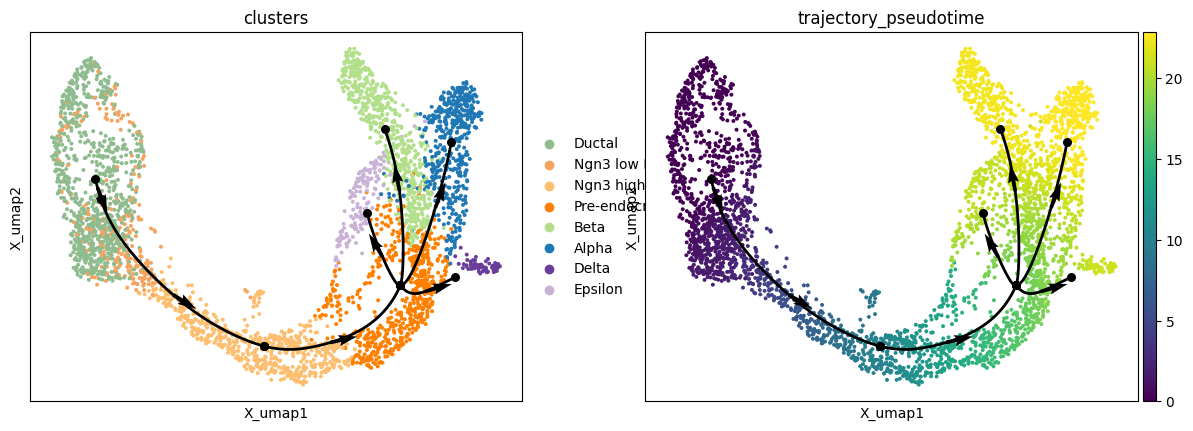

In [13]:
pseudotime_key = "trajectory_pseudotime"
fadata.obs[pseudotime_key] = fadata.get_trajectory_pseudotime()

cluster_key = "clusters"
cfe.plot.plot_trajectory(fadata, color=[cluster_key, pseudotime_key])

[09/16/2025 11:21:15] INFO     backend:'conda' is not available for method:'ti_paga', choosing new backend: 'dynverse_docker'                                                                           
                      DEBUG    Docker image(dynverse/ti_paga:v0.9.9.05) loaded, entry point is '['/code/run.py']'                                                                                       
                      INFO     method_backend: <cfe.method.fate_dynverse_docker_backend.DynverseDockerBackend object at 0x769619139420>                                                                 
                      DEBUG    extract .obs['clusters'](3696) in as prior information `groups_id` key for dynverse                                                                                      
                      DEBUG    Temp wd: /tmp/tmp84g50_58                                                                                                                                            

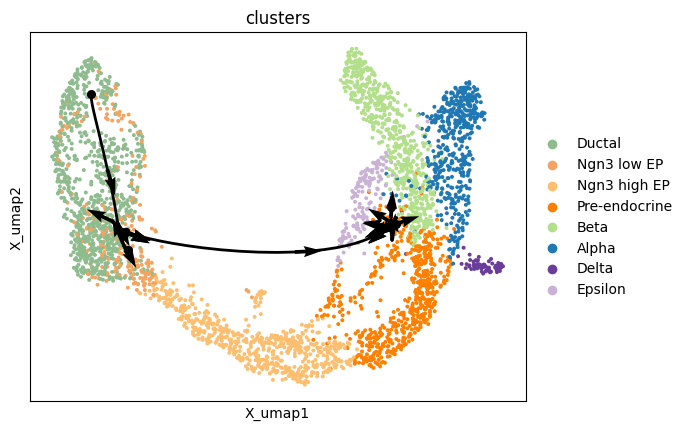

In [14]:
cfe.settings.dynverse_docker_via_json = False # write h5 directly

method2parameters = {
    "ti_paga": {},
}

for method_name, parameters in method2parameters.items():
    parameters["benchmark_resource"] = True
    method = cfe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)
    cfe.plot.plot_trajectory(fadata)

                      INFO     backend:'conda' is not available for method:'ti_paga', choosing new backend: 'dynverse_docker'                                                                           
                      DEBUG    Docker image(dynverse/ti_paga:v0.9.9.05) loaded, entry point is '['/code/run.py']'                                                                                       
[09/16/2025 11:23:41] INFO     method_backend: <cfe.method.fate_dynverse_docker_backend.DynverseDockerBackend object at 0x7696191210c0>                                                                 
                      DEBUG    extract .obs['clusters'](3696) in as prior information `groups_id` key for dynverse                                                                                      
                      DEBUG    Temp wd: /tmp/tmphf7iekqk                                                                                                                                            

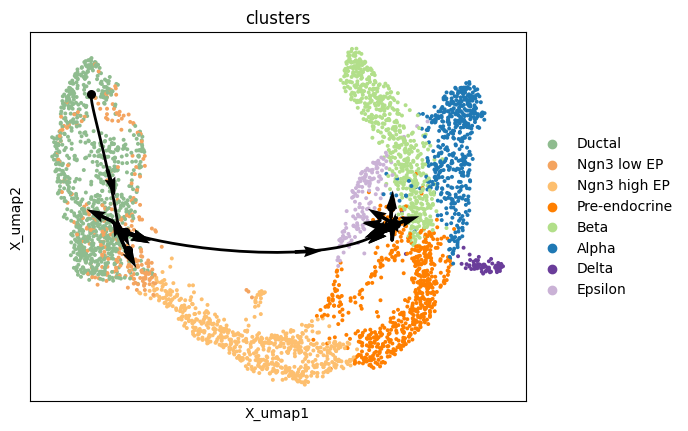

In [15]:
cfe.settings.dynverse_docker_via_json = True # write h5 via json

method2parameters = {
    "ti_paga": {},
}

for method_name, parameters in method2parameters.items():
    method = cfe.method.FateMethod(method_name=method_name)
    method.infer_trajectory(fadata, parameters=parameters)
    cfe.plot.plot_trajectory(fadata)

直接写入h5文件的优势：
- 更快：1s < 15s
- 更方便：用户不需要R语言环境(更重要的)